# Adaptive Optics: wavefront sensing from PSFs with a CNN (improved version of the original notebook)

This keeps the original three-phase structure (simulate -> train ResNet -> evaluate) and the original function names. Every change is tagged in the code:
`[ORIGINAL]` untouched, `[CHANGED]` fixed or improved, `[NEW]` added.

**Why the original gave PSNR ~11.8 dB / SSIM ~0.44**
1. PSF was **undersampled** (pupil filled the whole FFT grid, so lambda/D = 1 px; Nyquist needs 2 px).
2. **Read noise (0.1) was far above the signal** (PSF normalised to sum 1, so almost every pixel was ~0): the images were mostly noise.
3. A single PSF cannot give the **sign of even modes** (defocus, astigmatism, spherical), so MSE regression predicts ~0 for them. Fix: add a second, known-defocused PSF (phase diversity).
4. Zernike terms were not normalised, turbulence strength was fixed and spectrally flat, data were stored as uint8 PNGs, ImageNet normalisation was applied to PSFs, and the network's global pooling discarded PSF position (tip/tilt).
5. The network input is now sqrt-compressed intensity (the PSF core is ~1000x brighter than the halo).
6. PSNR/SSIM on per-image min-max normalised phase maps hides real error. We keep them for comparison, and add RMS wavefront error and Strehl ratio.

**v5 fixes (this version):** cells are in the correct order (model defined before training, one training cell, evaluation cell present); training uses AdamW + warm-up + cosine decay with no head dropout (measured on CPU: residual RMS 0.17 -> 0.095 rad at equal epochs); a per-epoch residual-RMS check makes a failed run obvious; each run saves to its own checkpoint (a good model is never overwritten); Strehl is measured at the on-axis pixel (tip/tilt counts); training photon counts are varied so the model also works in low light.

**Runs free:** no dataset or download needed. Uses a free GPU (Kaggle/Colab) if present, otherwise a smaller CPU profile.

In [1]:
# [CHANGED] imports/setup: torch imported up front so we can pick a GPU or CPU profile
import os, math, json, time, copy, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); HAS_GPU = device.type == 'cuda'
np.random.seed(42); torch.manual_seed(42)

GRID, PUPIL_PX = 64, 32          # [NEW] 64x64 grid, pupil diameter 32 px -> lambda/D = 2 px (Nyquist)
N_MODES, DIV_RAD = 16, 1.0       # [NEW] 16 Noll terms (as original); +1 rad RMS defocus for the diversity image
PHOTONS, READ_STD = 1e5, 5.0     # [CHANGED] noise now in photon / electron units
RMS_RANGE = (0.2, 1.0)           # [NEW] total turbulence RMS wavefront error (rad), random per sample
ARCH = 'resnet18' if HAS_GPU else 'small'
VARY_PHOTONS = True              # [NEW] train on photon counts 1e3..1e6 (log-uniform) so the model also works in low light; validation stays at PHOTONS
NUM_WORKERS = 2 if HAS_GPU else 0
PROFILE = dict(n_train=8000, n_val=1000, epochs=25, batch=128) if HAS_GPU else dict(n_train=3000, n_val=500, epochs=15, batch=64)
print('device:', device, '| model:', ARCH, '|', PROFILE)

device: cpu | model: small | {'n_train': 3000, 'n_val': 500, 'epochs': 15, 'batch': 64}


# Phase 1: Mathematical Formulation & Synthetic Physics Simulation

In [2]:
# [ORIGINAL] project directories
os.makedirs('ao_project/dataset/train/images', exist_ok=True)
os.makedirs('ao_project/dataset/train/labels', exist_ok=True)
os.makedirs('ao_project/dataset/val/images', exist_ok=True)
os.makedirs('ao_project/dataset/val/labels', exist_ok=True)
print("Directory structure created successfully.")

Directory structure created successfully.


In [3]:
import math

def polar_coordinates(size, pupil_px=None):
    """[CHANGED] Polar grids over a circular aperture. The pupil now has diameter pupil_px inside a size x size grid
    (zero padding), which is what gives a properly sampled PSF. Default keeps the pupil at half the grid."""
    pupil_px = pupil_px or size // 2
    x = (np.arange(size) - size / 2) / (pupil_px / 2)
    xx, yy = np.meshgrid(x, x)
    rho = np.sqrt(xx**2 + yy**2)
    theta = np.arctan2(yy, xx)
    mask = rho <= 1.0
    return rho, theta, mask

def get_zernike_polynomial(n, m, rho, theta):
    """[ORIGINAL] Computes the analytical Zernike polynomial Z^m_n."""
    radial = np.zeros_like(rho)
    m_abs = abs(m)
    if (n - m_abs) % 2 == 0:
        for k in range(0, (n - m_abs) // 2 + 1):
            num = ((-1)**k) * math.factorial(n - k)
            den = (math.factorial(k) *
                   math.factorial((n + m_abs) // 2 - k) *
                   math.factorial((n - m_abs) // 2 - k))
            radial += (num / den) * (rho**(n - 2*k))
    if m >= 0:
        return radial * np.cos(m * theta)
    else:
        return radial * np.sin(-m * theta)

def noll_norm(n, m):
    """[NEW] Noll normalisation: each mode has unit RMS over the aperture, so a coefficient equals its RMS wavefront error (rad)."""
    return math.sqrt(n + 1) if m == 0 else math.sqrt(2 * (n + 1))

In [4]:
# [ORIGINAL] Noll (n, m) mapping for the first 16 terms (checked: matches the standard Noll ordering)
zernike_modes = [
    (0, 0),   # Z1 (Piston)
    (1, 1),   # Z2 (Tip)
    (1, -1),  # Z3 (Tilt)
    (2, 0),   # Z4 (Defocus)
    (2, -2),  # Z5 (Astigmatism 45)
    (2, 2),   # Z6 (Astigmatism 0)
    (3, -1),  # Z7 (Coma Y)
    (3, 1),   # Z8 (Coma X)
    (3, -3),  # Z9 (Trefoil Y)
    (3, 3),   # Z10 (Trefoil X)
    (4, 0),   # Z11 (Spherical)
    (4, 2),   # Z12
    (4, -2),  # Z13
    (4, 4),   # Z14
    (4, -4),  # Z15
    (5, 1)    # Z16
]

# [NEW] precomputed normalised basis (16, GRID, GRID) on the padded grid
rho, theta, mask = polar_coordinates(GRID, PUPIL_PX); MASK = mask.astype(np.float64)
BASIS = np.stack([noll_norm(n, m) * get_zernike_polynomial(n, m, rho, theta) * MASK for n, m in zernike_modes])
A = BASIS.reshape(N_MODES, -1)[:, MASK.ravel() > 0]; gram = A @ A.T / MASK.sum()
print('basis orthonormality: max |offdiag| = %.3f, mean diag = %.3f' % (np.abs(gram - np.eye(N_MODES)).max(), np.diag(gram).mean()))

# [NEW] Kolmogorov-like fall-off of modal variance with radial order; total RMS drawn per sample
ORDER = np.array([n for n, m in zernike_modes], float)
SHAPE = np.zeros(N_MODES); SHAPE[1:] = ORDER[1:] ** (-11 / 6); SHAPE /= np.sqrt((SHAPE**2).sum())
def sample_coefficients(rms_range=RMS_RANGE):
    c = np.random.normal(0, 1, N_MODES) * SHAPE * np.random.uniform(*rms_range)
    c[0] = 0.0   # piston does not affect the PSF
    return c

basis orthonormality: max |offdiag| = 0.052, mean diag = 0.976


In [5]:
# [CHANGED] PSF rendering: Nyquist-sampled, noise in photon units, plus a phase-diversity (known defocus) image
def _psf_intensity(phase):
    pupil = MASK * np.exp(1j * phase)
    focal_field = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(pupil)))
    return np.abs(focal_field) ** 2

IDEAL_SUM  = _psf_intensity(np.zeros((GRID, GRID))).sum()
IDEAL_PEAK = _psf_intensity(np.zeros((GRID, GRID))).max()

def generate_wavefront_and_psf(coefficients, photon_count=PHOTONS, read_noise_std=READ_STD, diversity=True):
    """Renders aberrated PSF(s) from Zernike coefficients. Returns sqrt-intensity images (C,H,W) in [0,1] and the true phase."""
    phase = np.tensordot(coefficients, BASIS, axes=1) * MASK
    phases = [phase] + ([phase + DIV_RAD * BASIS[3]] if diversity else [])     # BASIS[3] = defocus
    imgs = []
    for ph in phases:
        psf = _psf_intensity(ph) / IDEAL_SUM * photon_count                    # expected photons per pixel
        noisy = np.random.poisson(psf).astype(np.float64) + np.random.normal(0, read_noise_std, psf.shape)
        noisy = np.clip(noisy, 0, None)
        imgs.append(np.sqrt(noisy / max(noisy.max(), 1e-6)))        # sqrt compresses the huge core/halo dynamic range
    return np.stack(imgs).astype(np.float32), phase

In [6]:
np.random.seed(42)

def build_dataset(num_samples, partition='train', photon_count=None, rms_range=RMS_RANGE):
    """[CHANGED] Generates a synthetic batch of PSF stacks + coefficient labels (float32 .npy instead of uint8 PNG)."""
    print(f"Generating {num_samples} samples for partition: {partition}...")
    for idx in range(num_samples):
        coeffs = sample_coefficients(rms_range)
        ph = photon_count if photon_count is not None else (10 ** np.random.uniform(3, 6) if (VARY_PHOTONS and partition == 'train') else PHOTONS)
        imgs, _ = generate_wavefront_and_psf(coeffs, ph)
        np.save(f'ao_project/dataset/{partition}/images/sample_{idx:05d}.npy', imgs)
        np.save(f'ao_project/dataset/{partition}/labels/sample_{idx:05d}.npy', coeffs.astype(np.float32))

def load_split(partition):
    """[NEW] Load a whole split into memory: X (N,2,H,W), C (N,16)."""
    ip = sorted(glob.glob(f'ao_project/dataset/{partition}/images/*.npy')); lp = sorted(glob.glob(f'ao_project/dataset/{partition}/labels/*.npy'))
    return np.stack([np.load(p) for p in ip]), np.stack([np.load(p) for p in lp])

def make_eval_set(n, photon_count=PHOTONS, rms_range=RMS_RANGE, diversity=True):
    """[NEW] In-memory test set at a chosen noise level / turbulence strength (used for the free sweeps)."""
    X, C = [], []
    for _ in range(n):
        c = sample_coefficients(rms_range); X.append(generate_wavefront_and_psf(c, photon_count, diversity=diversity)[0]); C.append(c)
    return np.stack(X), np.stack(C).astype(np.float32)

In [7]:
build_dataset(PROFILE['n_train'], 'train')
build_dataset(PROFILE['n_val'], 'val')
print("Dataset generation completed successfully.")

Generating 3000 samples for partition: train...
Generating 500 samples for partition: val...
Dataset generation completed successfully.


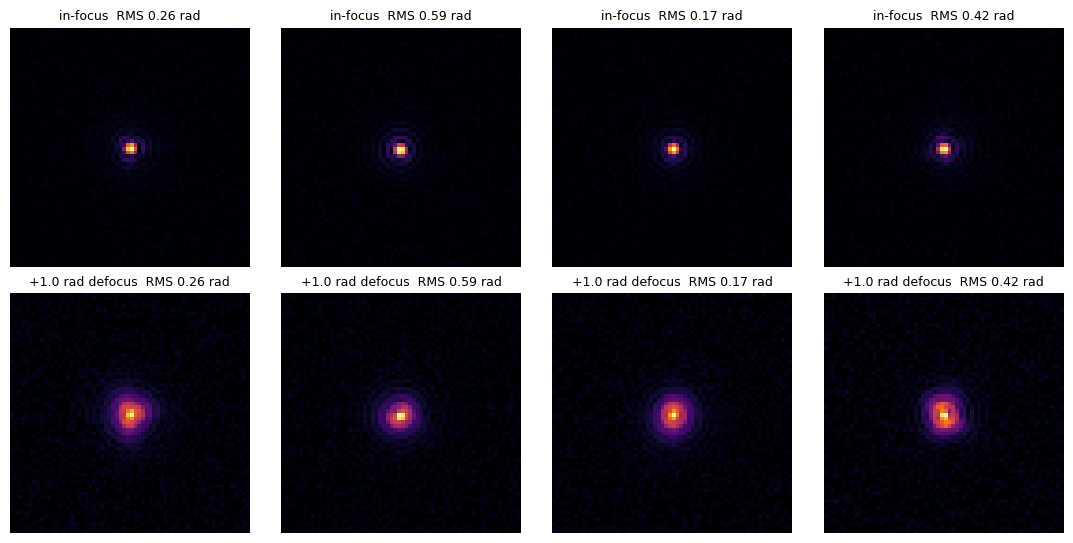

In [8]:
# [NEW] sanity check: what the network will see. Rings + distortions = good; pure speckle = something is wrong.
Xs, Cs = load_split('val'); fig, ax = plt.subplots(2, 4, figsize=(11, 5.5))
for i in range(4):
    for k, t in enumerate(['in-focus', f'+{DIV_RAD} rad defocus']):
        ax[k, i].imshow(Xs[i, k], cmap='inferno'); ax[k, i].axis('off'); ax[k, i].set_title(f'{t}  RMS {np.linalg.norm(Cs[i]):.2f} rad', fontsize=9)
plt.tight_layout(); plt.show()

# Phase 2: Neural Architecture & Regression Optimization

Same recipe as the original (PyTorch Dataset, ResNet-18 with a regression head, MSE, AdamW, ReduceLROnPlateau, best-checkpoint saving), with these changes:
2-channel float input instead of RGB/ImageNet-normalised PNG; ResNet trained from scratch with a small stride-2 stem; the head sees the full spatial map (no global average pooling, which discards PSF position and therefore tip/tilt); mixed precision on GPU.
A small CNN is used automatically on CPU.

In [9]:
from torchvision import models

class AODataset(Dataset):
    """[CHANGED] reads float32 .npy PSF stacks; `channels` selects in-focus only (0,) or in-focus + diversity (0, 1)."""
    def __init__(self, data_dir, channels=(0, 1)):
        self.image_paths = sorted(glob.glob(os.path.join(data_dir, 'images', '*.npy')))
        self.label_paths = sorted(glob.glob(os.path.join(data_dir, 'labels', '*.npy')))
        self.channels = list(channels)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.load(self.image_paths[idx])[self.channels].astype(np.float32)
        label = np.load(self.label_paths[idx]).astype(np.float32)   # 16 ground-truth Zernike coefficients
        return torch.from_numpy(img), torch.from_numpy(label)

def make_loaders(channels=(0, 1)):
    tr = AODataset('ao_project/dataset/train', channels); va = AODataset('ao_project/dataset/val', channels)
    return (DataLoader(tr, batch_size=PROFILE['batch'], shuffle=True, num_workers=NUM_WORKERS),
            DataLoader(va, batch_size=PROFILE['batch'], shuffle=False, num_workers=NUM_WORKERS))

train_loader, val_loader = make_loaders((0, 1))
print(f"Created train loader with {len(train_loader)} batches and validation loader with {len(val_loader)} batches.")

Created train loader with 47 batches and validation loader with 8 batches.


In [10]:
def get_ao_resnet18(num_targets=16, in_ch=2):
    """[CHANGED] ResNet-18 from scratch (ImageNet weights make no sense for 2-channel PSFs), small stride-2 stem, no pooling before the head."""
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(in_ch, 64, 3, 2, 1, bias=False)
    model.maxpool = nn.Identity(); model.avgpool = nn.Identity()       # keep spatial layout (4x4x512 for a 64x64 input)
    model.fc = nn.Sequential(nn.Linear(512 * 4 * 4, 256), nn.ReLU(), nn.Linear(256, num_targets))   # [CHANGED] dropout removed (it hurt precision)
    return model

def get_ao_small(num_targets=16, in_ch=2):
    """[NEW] ~2M-parameter CNN for CPU / quick ablations."""
    blk = lambda i, o, s: nn.Sequential(nn.Conv2d(i, o, 3, s, 1, bias=False), nn.BatchNorm2d(o), nn.ReLU(inplace=True))
    return nn.Sequential(blk(in_ch, 32, 1), blk(32, 32, 2), blk(32, 64, 1), blk(64, 64, 2), blk(64, 64, 1), blk(64, 64, 2),
                         nn.Flatten(), nn.Linear(64 * 8 * 8, 256), nn.ReLU(inplace=True), nn.Linear(256, num_targets))

def build_model(in_ch=2):
    return (get_ao_resnet18 if ARCH == 'resnet18' else get_ao_small)(num_targets=N_MODES, in_ch=in_ch).to(device)

model = build_model(2)
print(f"Initialized {ARCH} on device: {device} ({sum(p.numel() for p in model.parameters())/1e6:.1f} M parameters)")

Initialized small on device: cpu (1.2 M parameters)


In [11]:
import torch.optim as optim

def run_training(model, train_loader, val_loader, num_epochs, ckpt=None, lr=1e-3, weight_decay=1e-4, clip=1.0, warmup_epochs=1):
    """[CHANGED] AdamW + 1-epoch warm-up + cosine decay (measured much more accurate than ReduceLROnPlateau + dropout), gradient clipping,
    AMP on GPU, a per-epoch residual-RMS check, and one checkpoint file per run (auto-named so a good model is never overwritten)."""
    in_ch = len(train_loader.dataset.channels); ckpt = ckpt or f'best_{ARCH}_{in_ch}ch.pth'
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total, warm = num_epochs * len(train_loader), warmup_epochs * len(train_loader)
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lambda t: (t + 1) / warm if t < warm else 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * (t - warm) / max(1, total - warm))))
    scaler = torch.amp.GradScaler('cuda', enabled=HAS_GPU) if hasattr(torch.amp, 'GradScaler') else torch.cuda.amp.GradScaler(enabled=HAS_GPU)
    zero_baseline = float(np.mean(np.concatenate([(b[1] ** 2).mean(1).numpy() for b in val_loader])))     # val loss of predicting all zeros
    best_val_loss = float('inf'); best_model_wts = copy.deepcopy(model.state_dict()); train_losses, val_losses = [], []; t0 = time.time()
    print(f"Starting training ({ARCH}, {in_ch} channel(s)) -> {ckpt}. Predict-zero val loss = {zero_baseline:.5f} (a learning model must go far below this)")
    for epoch in range(num_epochs):
        model.train(); running_train_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device.type, dtype=torch.float16, enabled=HAS_GPU):
                outputs = model(inputs)
            loss = criterion(outputs.float(), labels)
            scaler.scale(loss).backward(); scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            running_train_loss += loss.item() * inputs.size(0)
        epoch_train_loss = running_train_loss / len(train_loader.dataset); train_losses.append(epoch_train_loss)

        model.eval(); running_val_loss = 0.0; r_in = r_out = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.autocast(device.type, dtype=torch.float16, enabled=HAS_GPU):
                    outputs = model(inputs)
                outputs = outputs.float(); running_val_loss += criterion(outputs, labels).item() * inputs.size(0)
                r_in += labels.norm(dim=1).sum().item(); r_out += (outputs - labels).norm(dim=1).sum().item()
        n = len(val_loader.dataset); epoch_val_loss = running_val_loss / n; val_losses.append(epoch_val_loss)
        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train {epoch_train_loss:.5f} | Val {epoch_val_loss:.5f} | residual RMS {r_out/n:.3f} vs input {r_in/n:.3f} rad | LR {optimizer.param_groups[0]['lr']:.1e} | {time.time()-t0:.0f}s")
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss; best_model_wts = copy.deepcopy(model.state_dict()); torch.save(best_model_wts, ckpt); print("--> New best model saved!")
        if epoch == 4 and best_val_loss > 0.7 * zero_baseline:
            print("WARNING: not learning (val loss still near the predict-zero baseline). Stop here, check the PSF plot above, and send me this log."); break
    model.load_state_dict(best_model_wts)
    print(f"Training complete. Best val loss {best_val_loss:.5f} (predict-zero: {zero_baseline:.5f}). Best weights restored from {ckpt}.")
    return train_losses, val_losses

# [CHANGED] The model is built in the cell above, so this cell must stay AFTER it. More epochs = better: raise PROFILE['epochs'] if time allows.
model = build_model(2)
train_losses, val_losses = run_training(model, train_loader, val_loader, PROFILE['epochs'])

Starting training (small, 2 channel(s)) -> best_small_2ch.pth. Predict-zero val loss = 0.02457 (a learning model must go far below this)
Epoch 01/15 | Train 0.01427 | Val 0.01057 | residual RMS 0.386 vs input 0.549 rad | LR 1.0e-03 | 47s
--> New best model saved!
Epoch 02/15 | Train 0.00333 | Val 0.00228 | residual RMS 0.178 vs input 0.549 rad | LR 9.9e-04 | 86s
--> New best model saved!
Epoch 03/15 | Train 0.00211 | Val 0.00147 | residual RMS 0.142 vs input 0.549 rad | LR 9.5e-04 | 126s
--> New best model saved!
Epoch 04/15 | Train 0.00157 | Val 0.00120 | residual RMS 0.129 vs input 0.549 rad | LR 8.9e-04 | 163s
--> New best model saved!
Epoch 05/15 | Train 0.00118 | Val 0.00125 | residual RMS 0.133 vs input 0.549 rad | LR 8.1e-04 | 201s
Epoch 06/15 | Train 0.00119 | Val 0.00086 | residual RMS 0.106 vs input 0.549 rad | LR 7.2e-04 | 238s
--> New best model saved!
Epoch 07/15 | Train 0.00095 | Val 0.00083 | residual RMS 0.106 vs input 0.549 rad | LR 6.2e-04 | 275s
--> New best model sa

# Phase 3: Quantitative Metric Evaluation & Inference

The original PSNR/SSIM numbers are still reported (for comparison with the original notebook), but the main metrics are now **residual RMS wavefront error** and **Strehl ratio** (before vs after applying the predicted correction), plus the uncorrected baseline.

In [12]:
@torch.no_grad()
def predict(model, X, channels=(0, 1), bs=250):
    """[NEW] batch inference on a numpy array X (N,2,H,W) -> predicted coefficients (N,16)."""
    model.eval(); out = []
    for i in range(0, len(X), bs):
        xb = torch.from_numpy(X[i:i + bs][:, list(channels)]).to(device)
        with torch.autocast(device.type, dtype=torch.float16, enabled=HAS_GPU):
            out.append(model(xb).float().cpu().numpy())
    return np.concatenate(out)

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

BOX = slice(GRID // 2 - PUPIL_PX // 2, GRID // 2 + PUPIL_PX // 2)   # [NEW] pupil bounding box: PSNR/SSIM are scored here, not on empty padding
MB = MASK[BOX, BOX] > 0

def reconstruct_wavefront(coeffs, size=GRID):
    """[CHANGED] Generates physical wavefront phase screen from Zernike coefficients (uses the precomputed basis)."""
    return np.tensordot(coeffs, BASIS, axes=1) * MASK

def strehl_of(c):
    """[CHANGED] Strehl ratio = on-axis PSF intensity / ideal peak (the physically meaningful definition)."""
    return _psf_intensity(reconstruct_wavefront(c))[GRID // 2, GRID // 2] / IDEAL_PEAK     # on-axis intensity: tip/tilt now counts

def ao_metrics(preds, gts):
    """[NEW] AO metrics: residual RMS WFE (rad) and Strehl before/after correction, per-mode RMSE."""
    preds = preds.copy(); preds[:, 0] = 0.0                      # piston is unobservable
    resid = gts - preds
    return dict(rms_in=float(np.linalg.norm(gts, axis=1).mean()), rms_out=float(np.linalg.norm(resid, axis=1).mean()),
                strehl_in=float(np.mean([strehl_of(g) for g in gts])), strehl_out=float(np.mean([strehl_of(r) for r in resid])),
                per_mode_rmse=np.sqrt((resid ** 2).mean(0)).tolist())

def original_psnr_ssim(preds, gts):
    """[ORIGINAL] per-map min-max normalised PSNR / SSIM (kept for comparison; optimistic). Now scored on the pupil box."""
    psnr_scores, ssim_scores = [], []
    for idx in range(len(preds)):
        gt_phase = reconstruct_wavefront(gts[idx])[BOX, BOX]; pred_phase = reconstruct_wavefront(preds[idx])[BOX, BOX]
        gt_norm = (gt_phase - gt_phase.min()) / (gt_phase.max() - gt_phase.min() + 1e-8)
        pred_norm = (pred_phase - pred_phase.min()) / (pred_phase.max() - pred_phase.min() + 1e-8)
        psnr_scores.append(psnr_metric(gt_norm, pred_norm, data_range=1.0)); ssim_scores.append(ssim_metric(gt_norm, pred_norm, data_range=1.0))
    return float(np.mean(psnr_scores)), float(np.mean(ssim_scores))

def fixed_range_psnr_ssim(preds, gts):
    """[NEW] PSNR/SSIM on un-normalised phase maps, one fixed data range, PSNR over pupil pixels only (amplitude errors count)."""
    G_ = [reconstruct_wavefront(g)[BOX, BOX] for g in gts]; P_ = [reconstruct_wavefront(p)[BOX, BOX] for p in preds]
    dr = float(max(np.ptp(g) for g in G_))
    psnr = [10 * np.log10(dr ** 2 / max(np.mean((g - p)[MB] ** 2), 1e-12)) for g, p in zip(G_, P_)]
    return float(np.mean(psnr)), float(np.mean([ssim_metric(g, p, data_range=dr) for g, p in zip(G_, P_)]))

In [13]:
X_val, C_val = load_split('val')
all_preds = predict(model, X_val, (0, 1)); all_gts = C_val
print(f"Completed validation inference on {all_preds.shape[0]} samples.")

mean_psnr, mean_ssim = original_psnr_ssim(all_preds, all_gts)           # [ORIGINAL] metrics
print(f"Mean Reconstruction PSNR (original, per-map normalised): {mean_psnr:.2f} dB")
print(f"Mean Reconstruction SSIM (original, per-map normalised): {mean_ssim:.4f}")
fp, fs = fixed_range_psnr_ssim(all_preds, all_gts); zp, zs = fixed_range_psnr_ssim(np.zeros_like(all_preds), all_gts)
print(f"[NEW] fixed-range PSNR / SSIM: {fp:.2f} dB / {fs:.4f}   (uncorrected baseline: {zp:.2f} dB / {zs:.4f})")

main = ao_metrics(all_preds, all_gts)
print(f"[NEW] RMS WFE : {main['rms_in']:.3f} -> {main['rms_out']:.3f} rad  ({(1 - main['rms_out'] / main['rms_in']) * 100:.0f}% reduction)")
print(f"[NEW] Strehl  : {main['strehl_in']:.3f} -> {main['strehl_out']:.3f}")
RESULTS = {'main': dict(arch=ARCH, channels=2, psnr_orig=mean_psnr, ssim_orig=mean_ssim, psnr_fixed=fp, ssim_fixed=fs, **main)}

Completed validation inference on 500 samples.
Mean Reconstruction PSNR (original, per-map normalised): 27.79 dB
Mean Reconstruction SSIM (original, per-map normalised): 0.9442
[NEW] fixed-range PSNR / SSIM: 41.46 dB / 0.9460   (uncorrected baseline: 24.57 dB / 0.1768)
[NEW] RMS WFE : 0.549 -> 0.077 rad  (86% reduction)
[NEW] Strehl  : 0.724 -> 0.993


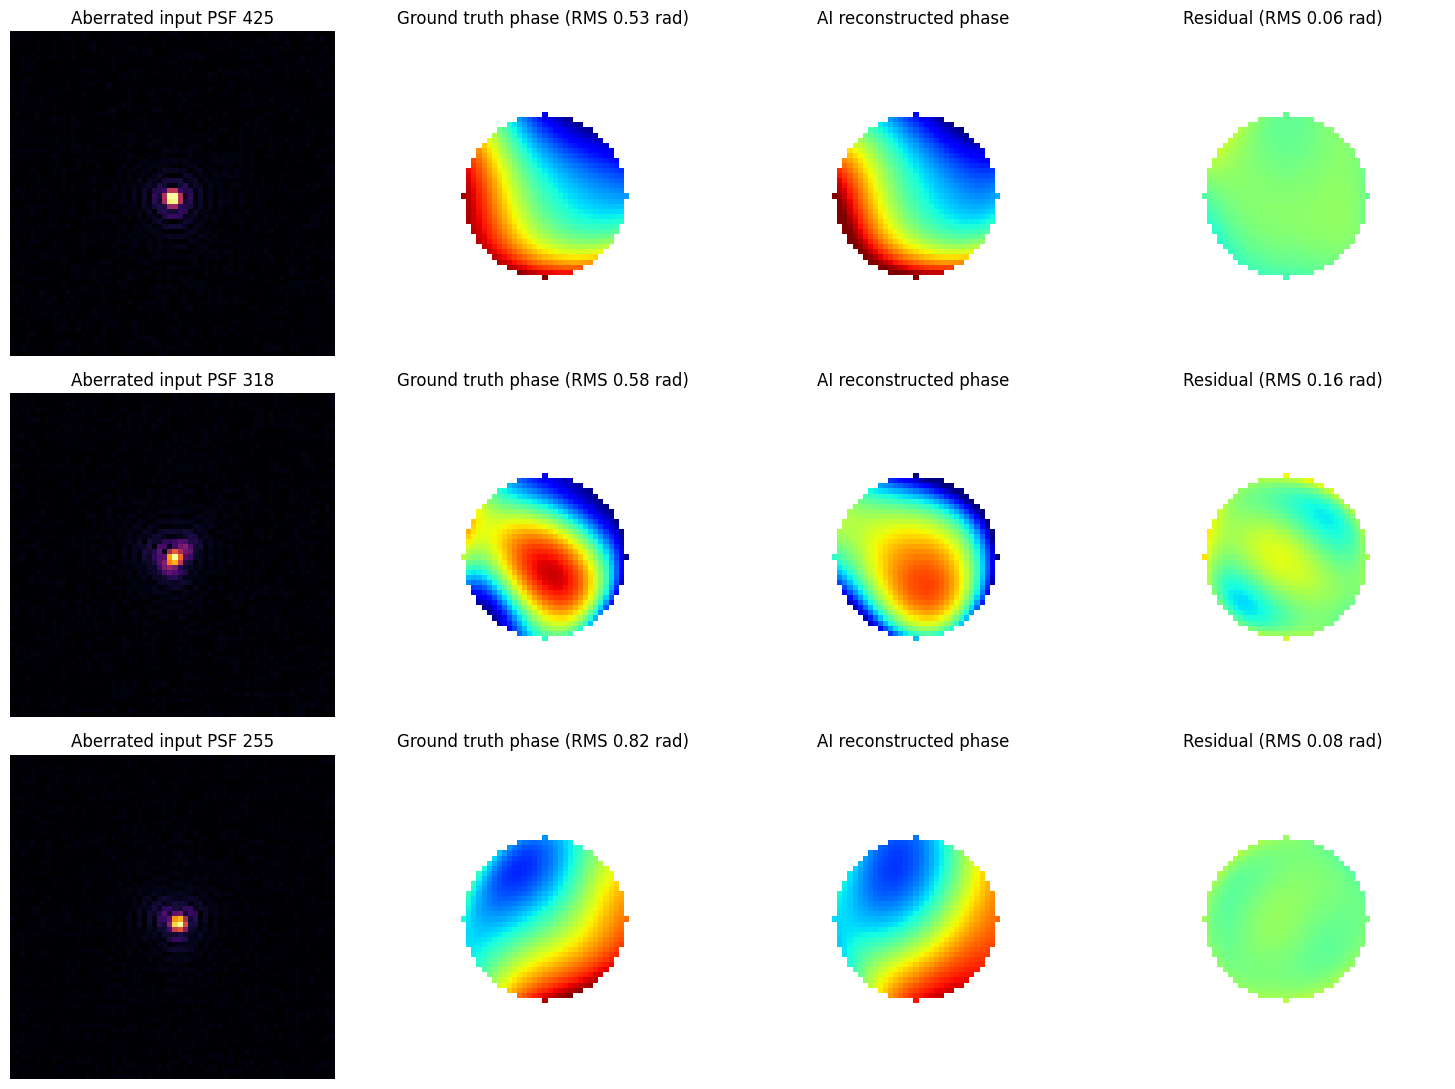

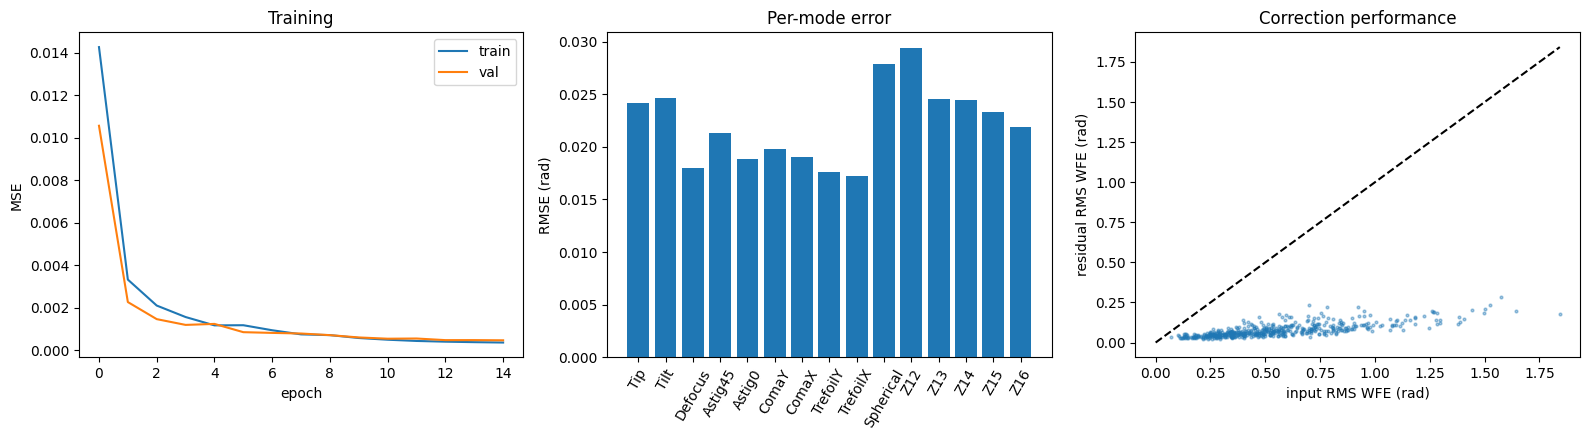

In [14]:
# [CHANGED] Publication-style comparison plots: shared colour scale for GT / prediction, plus a residual column
rng = np.random.default_rng(0); fig, axes = plt.subplots(3, 4, figsize=(15, 11))
for i in range(3):
    idx = int(rng.integers(0, len(all_preds)))
    gt_phase = reconstruct_wavefront(all_gts[idx]); pred_phase = reconstruct_wavefront(np.r_[0.0, all_preds[idx][1:]]); res = gt_phase - pred_phase
    show = lambda a: np.where(MASK > 0, a, np.nan); vmax = np.nanmax(np.abs(show(gt_phase)))
    axes[i, 0].imshow(X_val[idx, 0], cmap='inferno'); axes[i, 0].set_title(f"Aberrated input PSF {idx}")
    axes[i, 1].imshow(show(gt_phase), cmap='jet', vmin=-vmax, vmax=vmax); axes[i, 1].set_title(f"Ground truth phase (RMS {np.linalg.norm(all_gts[idx]):.2f} rad)")
    axes[i, 2].imshow(show(pred_phase), cmap='jet', vmin=-vmax, vmax=vmax); axes[i, 2].set_title("AI reconstructed phase")
    axes[i, 3].imshow(show(res), cmap='jet', vmin=-vmax, vmax=vmax); axes[i, 3].set_title(f"Residual (RMS {np.linalg.norm(all_gts[idx] - np.r_[0.0, all_preds[idx][1:]]):.2f} rad)")
    for a in axes[i]: a.axis('off')
plt.tight_layout(); os.makedirs('eval_outputs', exist_ok=True); plt.savefig('eval_outputs/wavefront_reconstructions_comparison.png', dpi=300); plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5)); mn = {1:'Tip',2:'Tilt',3:'Defocus',4:'Astig45',5:'Astig0',6:'ComaY',7:'ComaX',8:'TrefoilY',9:'TrefoilX',10:'Spherical'}
ax[0].plot(train_losses, label='train'); ax[0].plot(val_losses, label='val'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('MSE'); ax[0].legend(); ax[0].set_title('Training')
ax[1].bar(range(1, N_MODES), main['per_mode_rmse'][1:]); ax[1].set_xticks(range(1, N_MODES)); ax[1].set_xticklabels([mn.get(k, f'Z{k+1}') for k in range(1, N_MODES)], rotation=60); ax[1].set_ylabel('RMSE (rad)'); ax[1].set_title('Per-mode error')
ri = np.linalg.norm(all_gts, axis=1); ro = np.linalg.norm(all_gts - np.c_[np.zeros(len(all_preds)), all_preds[:, 1:]], axis=1)
ax[2].scatter(ri, ro, s=4, alpha=.4); ax[2].plot([0, ri.max()], [0, ri.max()], 'k--'); ax[2].set_xlabel('input RMS WFE (rad)'); ax[2].set_ylabel('residual RMS WFE (rad)'); ax[2].set_title('Correction performance')
plt.tight_layout(); plt.savefig('eval_outputs/results_overview.png', dpi=200); plt.show()

# Phase 4 [NEW]: Experiments for the comparison paper
Each is cheap and supports one claim. (1) phase diversity vs single PSF, (2) robustness to noise and turbulence, (3) CNN vs a classical model-based fit.

Starting training (small, 1 channel(s)) -> ablation_1ch.pth. Predict-zero val loss = 0.02457 (a learning model must go far below this)
Epoch 01/07 | Train 0.01317 | Val 0.01268 | residual RMS 0.408 vs input 0.549 rad | LR 1.0e-03 | 39s
--> New best model saved!
Epoch 02/07 | Train 0.00444 | Val 0.00448 | residual RMS 0.244 vs input 0.549 rad | LR 9.3e-04 | 78s
--> New best model saved!
Epoch 03/07 | Train 0.00412 | Val 0.00397 | residual RMS 0.227 vs input 0.549 rad | LR 7.5e-04 | 118s
--> New best model saved!
Epoch 04/07 | Train 0.00365 | Val 0.00394 | residual RMS 0.226 vs input 0.549 rad | LR 5.1e-04 | 158s
--> New best model saved!
Epoch 05/07 | Train 0.00336 | Val 0.00372 | residual RMS 0.218 vs input 0.549 rad | LR 2.6e-04 | 197s
--> New best model saved!
Epoch 06/07 | Train 0.00312 | Val 0.00365 | residual RMS 0.215 vs input 0.549 rad | LR 7.6e-05 | 236s
--> New best model saved!
Epoch 07/07 | Train 0.00299 | Val 0.00362 | residual RMS 0.214 vs input 0.549 rad | LR 1.0e-05 | 27

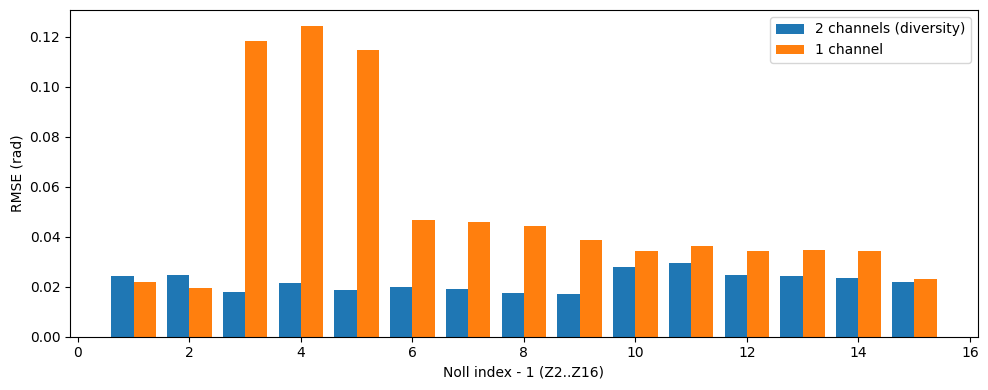

In [15]:
# 4.1 Ablation: single in-focus PSF (no phase diversity). Expect large errors on even modes (defocus, astigmatism, spherical).
loaders_1ch = make_loaders((0,)); model_1ch = build_model(1)
run_training(model_1ch, *loaders_1ch, max(5, PROFILE['epochs'] // 2), 'ablation_1ch.pth')
p1 = predict(model_1ch, X_val, (0,)); abl = ao_metrics(p1, all_gts)
RESULTS['ablation_1ch'] = dict(arch=ARCH, channels=1, **abl)
print(f"1-channel : RMS {abl['rms_in']:.3f} -> {abl['rms_out']:.3f} rad | Strehl {abl['strehl_in']:.3f} -> {abl['strehl_out']:.3f}")
print(f"2-channel : RMS {main['rms_in']:.3f} -> {main['rms_out']:.3f} rad | Strehl {main['strehl_in']:.3f} -> {main['strehl_out']:.3f}")
plt.figure(figsize=(10, 4)); w = 0.4
plt.bar(np.arange(1, N_MODES) - w/2, main['per_mode_rmse'][1:], w, label='2 channels (diversity)'); plt.bar(np.arange(1, N_MODES) + w/2, abl['per_mode_rmse'][1:], w, label='1 channel')
plt.xlabel('Noll index - 1 (Z2..Z16)'); plt.ylabel('RMSE (rad)'); plt.legend(); plt.tight_layout(); plt.savefig('eval_outputs/ablation_channels.png', dpi=200); plt.show()

--- photons per frame
      1000.0: RMS 0.565 -> 0.245 rad | Strehl 0.714 -> 0.938
      3000.0: RMS 0.561 -> 0.151 rad | Strehl 0.714 -> 0.976
     10000.0: RMS 0.516 -> 0.102 rad | Strehl 0.749 -> 0.989
    100000.0: RMS 0.542 -> 0.078 rad | Strehl 0.730 -> 0.992
   1000000.0: RMS 0.570 -> 0.075 rad | Strehl 0.705 -> 0.993
--- input RMS range (rad)
  (0.1, 0.3): RMS 0.181 -> 0.033 rad | Strehl 0.961 -> 0.999
  (0.3, 0.6): RMS 0.411 -> 0.055 rad | Strehl 0.826 -> 0.997
  (0.6, 1.0): RMS 0.686 -> 0.097 rad | Strehl 0.624 -> 0.990
  (1.0, 1.5): RMS 1.170 -> 0.260 rad | Strehl 0.356 -> 0.914


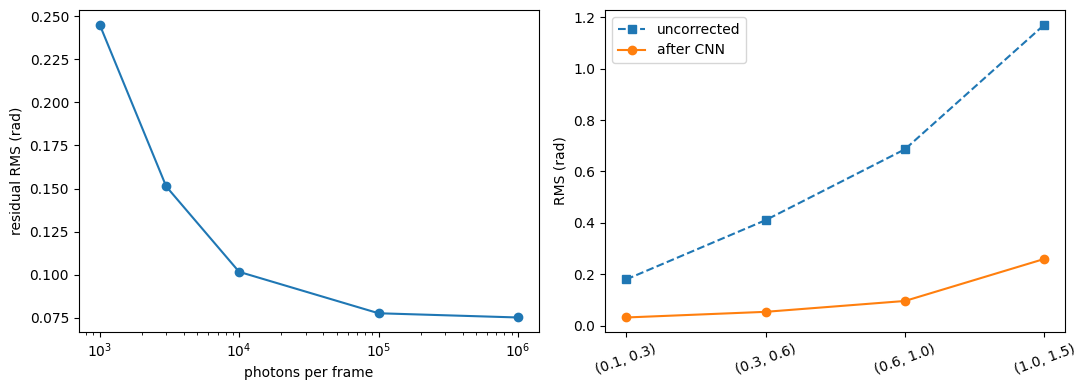

In [16]:
# 4.2 Free sweeps: test the trained 2-channel model at other photon levels / turbulence strengths (no retraining).
# NOTE: these test generalisation outside the training distribution; they are not the best accuracy achievable at each setting.
noise_sweep, turb_sweep = {}, {}
for ph in [1e3, 3e3, 1e4, 1e5, 1e6]:
    Xe, Ce = make_eval_set(300, photon_count=ph); noise_sweep[ph] = ao_metrics(predict(model, Xe), Ce)
for rr in [(0.1, 0.3), (0.3, 0.6), (0.6, 1.0), (1.0, 1.5)]:
    Xe, Ce = make_eval_set(300, rms_range=rr); turb_sweep[str(rr)] = ao_metrics(predict(model, Xe), Ce)
for name, sw in [('photons per frame', noise_sweep), ('input RMS range (rad)', turb_sweep)]:
    print('---', name)
    for k, v in sw.items(): print(f"{str(k):>12}: RMS {v['rms_in']:.3f} -> {v['rms_out']:.3f} rad | Strehl {v['strehl_in']:.3f} -> {v['strehl_out']:.3f}")
RESULTS['noise_sweep'] = {str(k): v for k, v in noise_sweep.items()}; RESULTS['turbulence_sweep'] = turb_sweep
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(list(noise_sweep), [v['rms_out'] for v in noise_sweep.values()], 'o-'); ax[0].set_xlabel('photons per frame'); ax[0].set_ylabel('residual RMS (rad)')
ax[1].plot([v['rms_in'] for v in turb_sweep.values()], 's--', label='uncorrected'); ax[1].plot([v['rms_out'] for v in turb_sweep.values()], 'o-', label='after CNN')
ax[1].set_xticks(range(len(turb_sweep))); ax[1].set_xticklabels(list(turb_sweep), rotation=20); ax[1].set_ylabel('RMS (rad)'); ax[1].legend()
plt.tight_layout(); plt.savefig('eval_outputs/sweeps.png', dpi=200); plt.show()

In [17]:
# 4.3 Classical-style baseline: fit the coefficients by gradient descent through the same physics (needs no training data).
B_t = torch.tensor(BASIS, dtype=torch.float32, device=device); M_t = torch.tensor(MASK, dtype=torch.float32, device=device)
def render_torch(c):
    phase = torch.einsum('bk,kxy->bxy', c, B_t); outs = []
    for p in (phase, phase + DIV_RAD * B_t[3]):
        f = torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(M_t * torch.exp(1j * p), dim=(-2, -1))), dim=(-2, -1))
        img = f.abs() ** 2; outs.append((img / img.amax(dim=(-2, -1), keepdim=True) + 1e-8).sqrt())   # same sqrt compression as the data
    return torch.stack(outs, 1)

def physics_fit(X_obs, iters=200, lr=0.05):
    c = (torch.randn(len(X_obs), N_MODES, device=device) * 0.05).requires_grad_(True); opt = torch.optim.Adam([c], lr=lr)
    for _ in range(iters):
        loss = (render_torch(c) - X_obs).pow(2).sum(dim=(1, 2, 3)).mean(); opt.zero_grad(); loss.backward(); opt.step()
    out = c.detach().cpu().numpy(); out[:, 0] = 0; return out

n_fit = min(200, len(X_val)); Xo = torch.tensor(X_val[:n_fit], device=device)
t0 = time.time(); c_fit = physics_fit(Xo); t_fit = time.time() - t0
fit = ao_metrics(c_fit, all_gts[:n_fit]); cnn = ao_metrics(all_preds[:n_fit], all_gts[:n_fit])
t0 = time.time(); _ = predict(model, X_val[:n_fit]); t_cnn = time.time() - t0
print(f"uncorrected : RMS {fit['rms_in']:.3f} rad | Strehl {fit['strehl_in']:.3f}")
print(f"physics fit : RMS {fit['rms_out']:.3f} rad | Strehl {fit['strehl_out']:.3f} | {t_fit:.1f} s for {n_fit} frames (iterative)")
print(f"CNN         : RMS {cnn['rms_out']:.3f} rad | Strehl {cnn['strehl_out']:.3f} | {t_cnn:.3f} s for {n_fit} frames (single forward pass)")
RESULTS['physics_fit'] = dict(seconds=t_fit, n=n_fit, **fit); RESULTS['cnn_same_subset'] = dict(seconds=t_cnn, **cnn)

uncorrected : RMS 0.520 rad | Strehl 0.743
physics fit : RMS 0.024 rad | Strehl 0.999 | 37.9 s for 200 frames (iterative)
CNN         : RMS 0.074 rad | Strehl 0.993 | 0.711 s for 200 frames (single forward pass)


In [18]:
# [NEW] save everything for the paper
json.dump(RESULTS, open('eval_outputs/results.json', 'w'), indent=1)
import pandas as pd
rows = [dict(experiment=k, **{m: round(v[m], 3) for m in ['rms_in', 'rms_out', 'strehl_in', 'strehl_out']}) for k, v in RESULTS.items() if isinstance(v, dict) and 'rms_out' in v]
display(pd.DataFrame(rows))

,experiment,rms_in,rms_out,strehl_in,strehl_out
0,main,0.549,0.077,0.724,0.993
1,ablation_1ch,0.549,0.214,0.724,0.947
2,physics_fit,0.520,0.024,0.743,0.999
3,cnn_same_subset,0.520,0.074,0.743,0.993
